In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys

sys.path.append('./..')

import numpy as np
import matplotlib.pyplot as plt

# Figures for Master's Thesis

## 3. Individual Model of Spatial Learning Traps

### 3.2 Design of the search problem

#### 3.2.2 Kernel misspecification

In [ ]:
from thesis.utils import plot_MAB
from thesis.rewards import sample_RBF_GP, sample_Gabor_GP, sample_DoG_GP

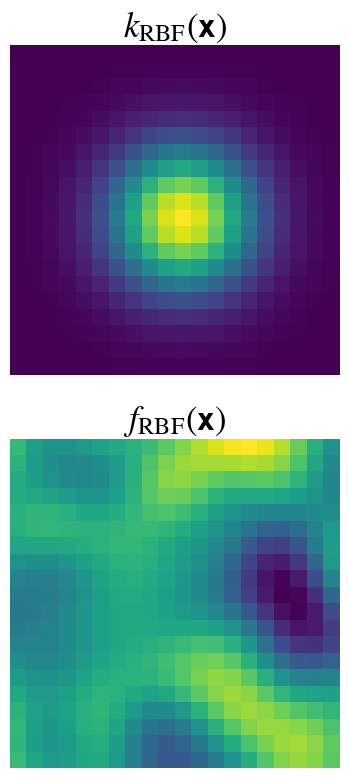

In [ ]:
rng = np.random.default_rng(42)
grid_size    = 20
length_scale = 3

# 1. Sample RBF GP
f_RBF, k_RBF = sample_RBF_GP(
    rng=rng,
    n=grid_size,
    length_scale=length_scale,
)
title_RBF = [
    r'$k_\text{RBF}(\mathbf{\mathsf{x}})$',
    r'$f_\text{RBF}(\mathbf{\mathsf{x}})$'
]

plot_MAB(f_RBF, k_RBF, title=title_RBF)

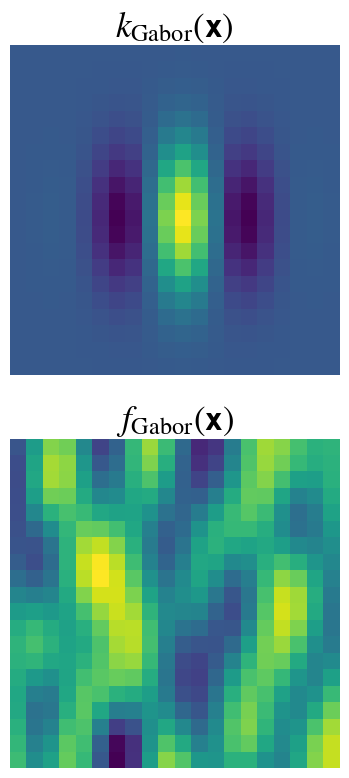

In [105]:
# rng   = np.random.default_rng(42)
w     = 1 - 1/length_scale**2
sigma = 1 * length_scale

# 2. Sample Gabor GP
f_Gabor, k_Gabor = sample_Gabor_GP(
    rng=rng,
    n=grid_size,
    frequency=w,
    sigma=sigma,
    theta=0,
)
title_Gabor = [
    r'$k_\text{Gabor}(\mathbf{\mathsf{x}})$',
    r'$f_\text{Gabor}(\mathbf{\mathsf{x}})$'
]

plot_MAB(f_Gabor, k_Gabor, title=title_Gabor)

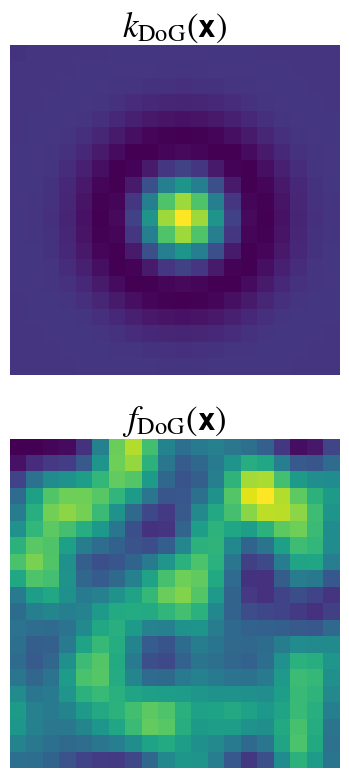

In [74]:
# rng   = np.random.default_rng(42)

# 3. Sample DoG GP
f_DoG, k_DoG = sample_DoG_GP(
    rng=rng,
    n=grid_size,
    sigma_outer=length_scale,
    sigma_inner=length_scale/2,
)
title_DoG = [
    r'$k_\text{DoG}(\mathbf{\mathsf{x}})$',
    r'$f_\text{DoG}(\mathbf{\mathsf{x}})$'
]

plot_MAB(f_DoG, k_DoG, title=title_DoG)

#### 3.2.6 Mexican Hat manipulation

In [ ]:
from thesis.rewards import _mexican_hat_rbf, create_mexican_hat_MAB

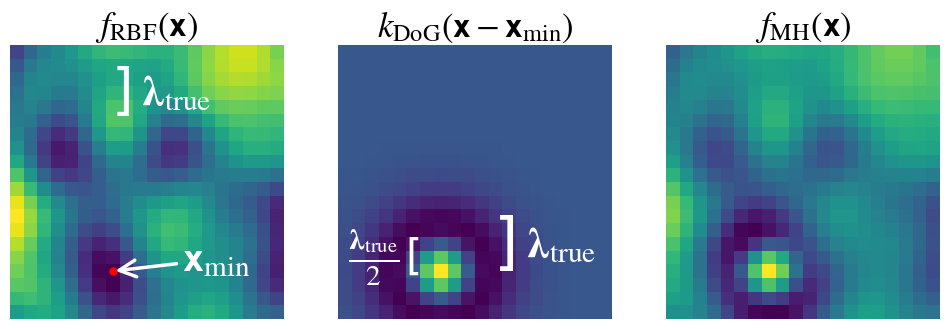

In [229]:
fig, ax  = plt.subplots(1, 3, figsize=(12, 4))
lambda_true = 3
sigma_outer = lambda_true
sigma_inner = sigma_outer / 2
font_size = 30

# 1.a Sample RBF GP
rng = np.random.default_rng(43)
f_RBF, _ = sample_RBF_GP(
    rng=rng,
    n=20,
    length_scale=lambda_true,
)
# 1.b Plot RBF GP
ax[0].imshow(f_RBF, cmap='viridis', origin='lower')
ax[0].axis('off')
ax[0].set_title(r'$f_\text{RBF}(\mathbf{\mathsf{x}})$', fontsize=25)

# 2.a Find minimum
x_min = np.unravel_index(np.argmin(f_RBF), f_RBF.shape)
x_min_xy = (x_min[1], x_min[0])
ax[0].plot(*x_min_xy, marker='.', markersize=12, markerfacecolor='red',
           markeredgecolor='none', markeredgewidth=2)
ax[0].annotate(r'$\mathbf{\mathsf{x}}_{\mathrm{min}}$', xy=x_min_xy, xytext=(50, 0),
               textcoords='offset points', color='white', fontsize=font_size,
               arrowprops=dict(arrowstyle='->', color='white', lw=2.5))
ax[0].text(7.7, 16, ']', color='white', fontsize=40, ha='center', va='center')
ax[0].text(9.1, 16, r'$\boldsymbol{\lambda}_{\mathrm{true}}$',
           color='white', fontsize=font_size, ha='left', va='center')
# 2.b Create DoG kernel centered at the minimum
k_DoG = _mexican_hat_rbf(20, sigma_outer, sigma_inner, center=x_min)
# 2.c Plot DoG kernel
ax[1].imshow(k_DoG, cmap='viridis', origin='lower')
ax[1].axis('off')
ax[1].set_title(r'$k_\text{DoG}(\mathbf{\mathsf{x}}-\mathbf{\mathsf{x}}_\text{min})$', fontsize=25)
ax[1].text(11.8, 4.9, ']', color='white', fontsize=45, ha='center', va='center')
ax[1].text(13.2, 4.9,
           r'$\boldsymbol{\lambda}_{\mathrm{true}}$',
           color='white', fontsize=font_size, ha='left', va='center')
ax[1].text(5, 4, '[', color='white', fontsize=30, ha='center', va='center')
ax[1].text(0.2, 4,
           r'$\frac{\boldsymbol{\lambda}_{\mathrm{true}}}{2}$',
           color='white', fontsize=font_size, ha='left', va='center')

# 3.a Create Mexican Hat MAB
f_MH = create_mexican_hat_MAB(
    rng=np.random.default_rng(43),
    n=20,
    length_scale=lambda_true,
    sigma_outer=sigma_outer,
    sigma_inner=sigma_inner,
    x_min=x_min,
    local_global_max_ratio=1.2,
)
ax[2].imshow(f_MH[0], cmap='viridis', origin='lower')
ax[2].axis('off')
ax[2].set_title(r'$f_\text{MH}(\mathbf{\mathsf{x}})$', fontsize=25)

plt.show()


### 3.3 Results